In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

Proportion of women with local recurrence: 0.7120
Average simulated lifetime: 22.09 years


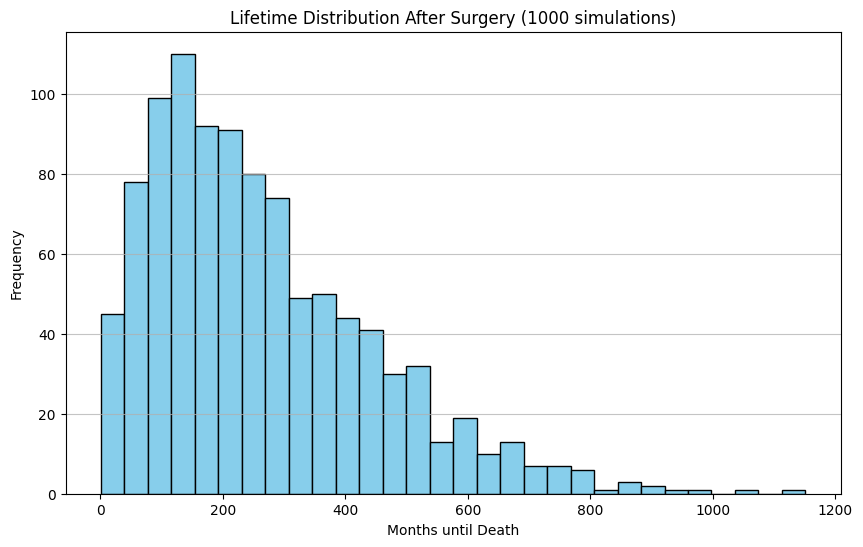

In [25]:
P = np.array([[0.9915, 0.005, 0.0025, 0, 0.001],
              [0, 0.986, 0.005, 0.004, 0.005],
              [0, 0, 0.992, 0.003, 0.005],
              [0, 0, 0, 0.991, 0.009],
              [0, 0, 0, 0, 1]])


state_labels = ["State 1 (Post-surgery)", "State 2 (Local Recurrence)", "State 3 (Distant Metastasis)", "State 4 (Both Recurrence)", "State 5 (Death)"]

num_women = 1000
lifetimes = []
local_recurrence_count = 0

np.random.seed(42) # For reproducible results

# 2. Simulate 1000 women
for _ in range(num_women):
    state = 0 # 0-indexed for State 1 (Post-surgery)
    months = 0
    had_local = False
    
    # Continue simulation until State 5 (index 4, Death) is reached
    while state != 4: 
        # Check if patient enters State 2 (index 1) or State 4 (index 3)
        if state == 1 or state == 3:
            had_local = True
            
        # Randomly transition to the next state based on the current state's row in P
        state = np.random.choice(5, p=P[state])
        months += 1
        
    lifetimes.append(months)
    if had_local:
        local_recurrence_count += 1

# 3. Summarize results
proportion_local = local_recurrence_count / num_women
print(f"Proportion of women with local recurrence: {proportion_local:.4f}")
print(f"Average simulated lifetime: {np.mean(lifetimes)/12:.2f} years")

# 4. Plot the lifetime distribution histogram
plt.figure(figsize=(10, 6))
plt.hist(lifetimes, bins=30, color='skyblue', edgecolor='black')
plt.title('Lifetime Distribution After Surgery (1000 simulations)')
plt.xlabel('Months until Death')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.savefig("lifetime_distribution.png")

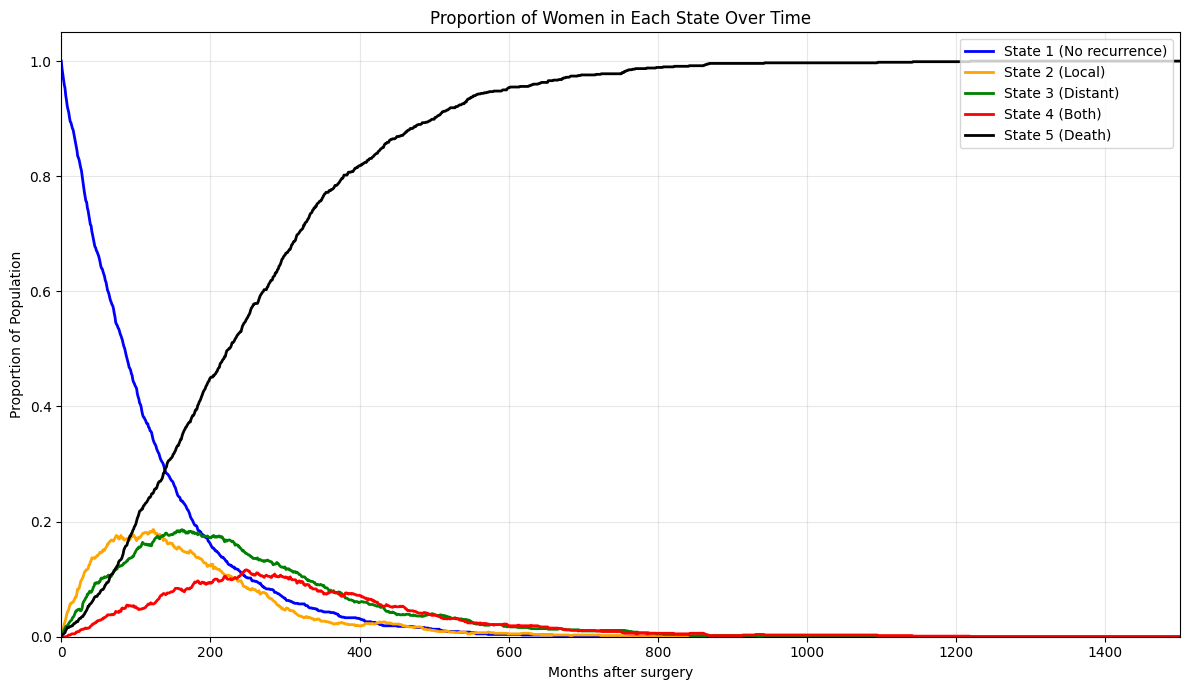

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Define the probability transition matrix P
P = np.array([
    [0.9915, 0.005, 0.0025, 0,     0.001],
    [0,      0.986, 0.005,  0.004, 0.005],
    [0,      0,     0.992,  0.003, 0.005],
    [0,      0,     0,      0.991, 0.009],
    [0,      0,     0,      0,     1.0  ]
])

num_women = 1000
max_months = 1500  # Set a timeframe to observe (e.g., 350 months as mentioned later in the assignment)

# Initialize an array to store the count of women in each state at each month
# Rows = months, Columns = states
state_counts_over_time = np.zeros((max_months, 5))

# All women start in State 1 (Index 0)
current_states = np.zeros(num_women, dtype=int)

# Run the simulation month by month for the whole population
for month in range(max_months):
    # 1. Record the current distribution of states for this month
    for state in range(5):
        state_counts_over_time[month, state] = np.sum(current_states == state)
        
    # 2. Transition each woman to her next state
    for i in range(num_women):
        if current_states[i] != 4:  # If not in the absorbing state (Death)
            current_states[i] = np.random.choice(5, p=P[current_states[i]])

# Convert counts to proportions
proportions_over_time = state_counts_over_time / num_women

# --- Plotting the Results ---
# Your pre-defined state labels
state_labels = ['State 1 (No recurrence)', 'State 2 (Local)', 'State 3 (Distant)', 'State 4 (Both)', 'State 5 (Death)']

plt.figure(figsize=(12, 7))

# Plot a line for each state
colors = ['blue', 'orange', 'green', 'red', 'black']
for state in range(5):
    plt.plot(proportions_over_time[:, state], label=state_labels[state], color=colors[state], linewidth=2)

plt.title('Proportion of Women in Each State Over Time')
plt.xlabel('Months after surgery')
plt.ylabel('Proportion of Population')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(0, max_months)
plt.ylim(0, 1.05) # Cap y-axis slightly above 1 for visibility

plt.tight_layout()
plt.show()

In [49]:
import numpy as np
from scipy.stats import chisquare
np.random.seed(42)  # For reproducibility
# Define the probability transition matrix P (if running independently)
P = np.array([
    [0.9915, 0.005, 0.0025, 0,     0.001],
    [0,      0.986, 0.005,  0.004, 0.005],
    [0,      0,     0.992,  0.003, 0.005],
    [0,      0,     0,      0.991, 0.009],
    [0,      0,     0,      0,     1.0  ]
])

num_women = 1000
t_target = 120

# --- 1. Theoretical Distribution ---
# Initial state vector: All women start in state 1 (index 0)
p_0 = np.array([1, 0, 0, 0, 0]) 

# Calculate P^120
P_120 = np.linalg.matrix_power(P, t_target)

# Calculate the theoretical distribution at t=120
theoretical_probabilities = p_0 @ P_120
expected_frequencies = theoretical_probabilities * num_women

# --- 2. Empirical Distribution ---
observed_states = []

for _ in range(num_women):
    current_state = 0
    # Simulate for exactly 120 steps
    for _ in range(t_target):
        if current_state == 4: # Death is an absorbing state
            break
        current_state = np.random.choice(5, p=P[current_state])
    
    observed_states.append(current_state)

# Count how many women are in each state at t=120
observed_frequencies = [observed_states.count(i) for i in range(5)]

# --- 3. Statistical Analysis ---
print("--- Results at t=120 ---")
for i in range(5):
    print(f"State {i+1}: Expected = {expected_frequencies[i]:.1f}, Observed = {observed_frequencies[i]}")

# Perform the Chi-Square Goodness-of-Fit test
chi_stat, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)

print("\n--- Chi-Square Test ---")
print(f"Chi-square statistic: {chi_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value > 0.05:
    print("Conclusion: We fail to reject the null hypothesis.")
    print("The simulated distribution corresponds well with the theoretical expectation.")
else:
    print("Conclusion: We reject the null hypothesis.")
    print("The simulated distribution differs significantly from the theoretical expectation.")

--- Results at t=120 ---
State 1: Expected = 359.0, Observed = 362
State 2: Expected = 159.0, Observed = 157
State 3: Expected = 166.1, Observed = 186
State 4: Expected = 67.7, Observed = 69
State 5: Expected = 248.2, Observed = 226

--- Chi-Square Test ---
Chi-square statistic: 4.4434
P-value: 0.3493
Conclusion: We fail to reject the null hypothesis.
The simulated distribution corresponds well with the theoretical expectation.


--- Mean Lifetime Comparison ---
Empirical Mean (Simulation): 265.04 months
Theoretical Mean E(T):       262.37 months


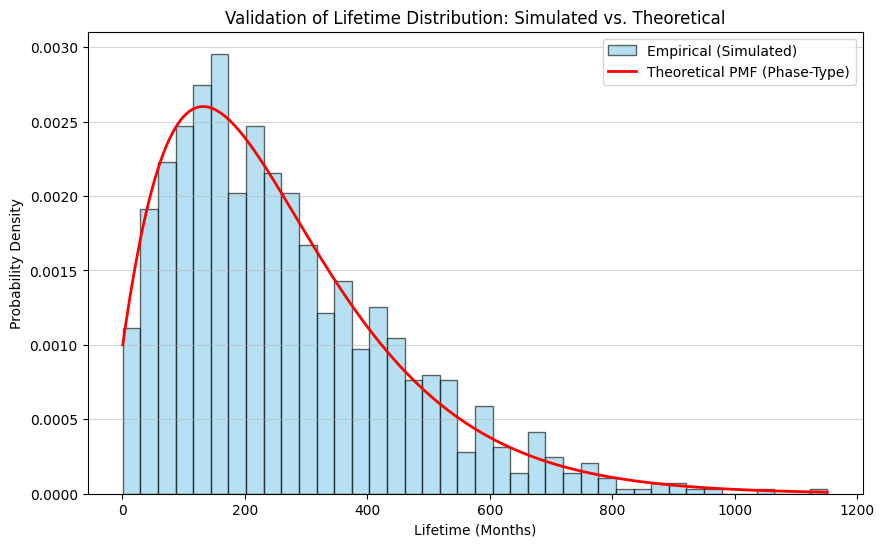

In [50]:
# 1. Define the full probability transition matrix P
np.random.seed(42)  # For reproducibility

# 2. Re-run simulation to get empirical lifetimes (Task 1 setup)
num_women = 1000
lifetimes = []

for _ in range(num_women):
    current_state = 0
    lifetime_months = 0
    while current_state != 4:
        current_state = np.random.choice(5, p=P[current_state])
        lifetime_months += 1
    lifetimes.append(lifetime_months)

empirical_mean = np.mean(lifetimes)

# 3. Setup Theoretical Variables for Task 3
# pi is the initial distribution over transient states 1,2,3,4
pi = np.array([1, 0, 0, 0]) 

# P_s is the 4x4 sub-matrix (removing the 5th row and column, which is the death state)
P_s = P[0:4, 0:4]

# p_s is the column vector of death probabilities from states 1,2,3,4 (the 5th column)
p_s = P[0:4, 4]

# Identity matrix I and vector of ones
I = np.eye(4)
ones = np.ones(4)

# 4. Calculate Theoretical Expected Lifetime E(T)
# Formula: E(T) = pi * (I - P_s)^(-1) * 1
inverse_matrix = np.linalg.inv(I - P_s)
theoretical_mean = pi @ inverse_matrix @ ones

print("--- Mean Lifetime Comparison ---")
print(f"Empirical Mean (Simulation): {empirical_mean:.2f} months")
print(f"Theoretical Mean E(T):       {theoretical_mean:.2f} months")

# 5. Calculate Theoretical Probability Mass Function (PMF)
# We will calculate the theoretical probability for each month up to the max simulated lifetime
max_t = max(lifetimes)
t_values = np.arange(1, max_t + 1)
theoretical_pmf = []

for t in t_values:
    P_s_power_t_minus_1 = np.linalg.matrix_power(P_s, t - 1)
    prob_t = pi @ P_s_power_t_minus_1 @ p_s
    theoretical_pmf.append(prob_t)

theoretical_pmf = np.array(theoretical_pmf)

# 6. Plotting the Comparison
plt.figure(figsize=(10, 6))

# Plot empirical histogram (using density=True so the y-axis is a probability, not a raw count)
plt.hist(lifetimes, bins=40, density=True, color='skyblue', edgecolor='black', alpha=0.6, label='Empirical (Simulated)')

# Overlay theoretical PMF curve
plt.plot(t_values, theoretical_pmf, color='red', linewidth=2, label='Theoretical PMF (Phase-Type)')

plt.title('Validation of Lifetime Distribution: Simulated vs. Theoretical')
plt.xlabel('Lifetime (Months)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.savefig("lifetime_comparison.png")
plt.show()

In [38]:
import numpy as np
from scipy.stats import chisquare

num_women = 1000
lifetimes = []
np.random.seed(42) 
for _ in range(num_women):
    current_state = 0
    lifetime_months = 0
    while current_state != 4:
        current_state = np.random.choice(5, p=P[current_state])
        lifetime_months += 1
    lifetimes.append(lifetime_months)

pi = np.array([1, 0, 0, 0]) 
P_s = P[0:4, 0:4]
ones = np.ones(4)


bin_edges = [0, 24, 48, 72, 96, 120, 144, 168, 192, 216, 240, 300, 400, float('inf')]

observed_counts, _ = np.histogram(lifetimes, bins=bin_edges)

def calculate_cdf(t):
    if t == 0:
        return 0.0
    if t == float('inf'):
        return 1.0
    return 1.0 - (pi @ np.linalg.matrix_power(P_s, int(t)) @ ones)

expected_probs = []
for i in range(len(bin_edges) - 1):
    lower_bound = bin_edges[i]
    upper_bound = bin_edges[i+1]
    
    # Probability of falling in this bin is CDF(upper) - CDF(lower)
    prob = calculate_cdf(upper_bound) - calculate_cdf(lower_bound)
    expected_probs.append(prob)

expected_counts = np.array(expected_probs) * num_women

# 6. Perform the Chi-Square Test
# We only test bins where the expected count is > 0 to avoid division by zero errors
valid_indices = expected_counts > 0
f_obs_valid = observed_counts[valid_indices]
f_exp_valid = expected_counts[valid_indices]

# Optional: Ensure minimum expected counts >= 5 by combining tail bins if necessary
# For 1000 samples and these wide bins, they should naturally be >= 5, but it's good practice to note.

chi_stat, p_value = chisquare(f_obs=f_obs_valid, f_exp=f_exp_valid)

print("--- Data Bins ---")
for i in range(len(bin_edges) - 1):
    print(f"Months {bin_edges[i]:3} to {str(bin_edges[i+1]):<4}: Observed = {observed_counts[i]:3}, Expected = {expected_counts[i]:.1f}")

print("\n--- Chi-Square Test Results ---")
print(f"Chi-square statistic: {chi_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value > 0.05:
    print("Conclusion: We fail to reject the null hypothesis.")
    print("The simulated lifetimes follow the theoretical discrete phase-type distribution.")
else:
    print("Conclusion: We reject the null hypothesis.")
    print("The simulated lifetimes significantly deviate from the theoretical distribution.")

--- Data Bins ---
Months   0 to 24  : Observed =  21, Expected = 31.4
Months  24 to 48  : Observed =  40, Expected = 44.0
Months  48 to 72  : Observed =  54, Expected = 52.9
Months  72 to 96  : Observed =  57, Expected = 58.5
Months  96 to 120 : Observed =  59, Expected = 61.5
Months 120 to 144 : Observed =  66, Expected = 62.4
Months 144 to 168 : Observed =  73, Expected = 61.6
Months 168 to 192 : Observed =  53, Expected = 59.7
Months 192 to 216 : Observed =  55, Expected = 56.9
Months 216 to 240 : Observed =  56, Expected = 53.5
Months 240 to 300 : Observed = 119, Expected = 116.9
Months 300 to 400 : Observed = 129, Expected = 142.0
Months 400 to inf : Observed = 218, Expected = 198.9

--- Chi-Square Test Results ---
Chi-square statistic: 10.2425
P-value: 0.5947
Conclusion: We fail to reject the null hypothesis.
The simulated lifetimes follow the theoretical discrete phase-type distribution.


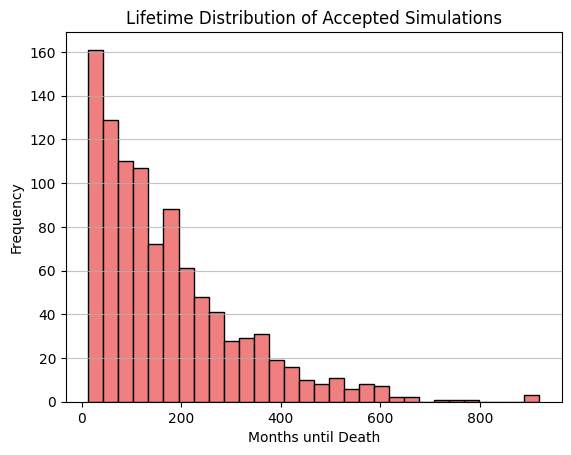

Total valid simulations collected: 1000
Estimated expected lifetime: 172.68 months


In [41]:
accepted_lifetimes = []
target_simulations = 1000
np.random.seed(42)  

while len(accepted_lifetimes) < target_simulations:
    current_state = 0  # Start in State 1
    lifetime_months = 0
    recurrence_within_12 = False
    
    for _ in range(12):
        current_state = np.random.choice(5, p=P[current_state])
        lifetime_months += 1
        
        if current_state in [1, 2, 3]:
            recurrence_within_12 = True
            
        if current_state == 4:
            break
            
    
    if current_state != 4 and recurrence_within_12:
        
        while current_state != 4:
            current_state = np.random.choice(5, p=P[current_state])
            lifetime_months += 1
            
        accepted_lifetimes.append(lifetime_months)

expected_lifetime = np.mean(accepted_lifetimes)
plt.hist(accepted_lifetimes, bins=30, color='lightcoral', edgecolor='black')
plt.title('Lifetime Distribution of Accepted Simulations')
plt.xlabel('Months until Death')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
# plt.savefig("accepted_lifetime_distribution.png")
plt.show()
print(f"Total valid simulations collected: {len(accepted_lifetimes)}")
print(f"Estimated expected lifetime: {expected_lifetime:.2f} months")

In [40]:
import numpy as np
np.random.seed(42)  # For reproducibility
# 2. Calculate the Theoretical Expected Lifetime (E[X])
pi = np.array([1, 0, 0, 0])
P_s = P[0:4, 0:4]
I = np.eye(4)
ones = np.ones(4)

# true_mean is E(T) from Task 3
true_mean = pi @ np.linalg.inv(I - P_s) @ ones

# 3. Setup Simulation Parameters
n_women = 200
n_reps = 100

# Arrays to store results of the 100 repetitions
Y_crude = np.zeros(n_reps)  # Fraction dying <= 350 months
X_control = np.zeros(n_reps) # Mean lifetime of the 200 women

print("Running 100 simulations of 200 women. This may take a moment...")

# 4. Run the Monte Carlo Simulation
for i in range(n_reps):
    lifetimes = np.zeros(n_women)
    
    for j in range(n_women):
        current_state = 0
        t = 0
        while current_state != 4:
            current_state = np.random.choice(5, p=P[current_state])
            t += 1
        lifetimes[j] = t
        
    # Record the fraction of deaths <= 350 months (Y) and the mean lifetime (X)
    Y_crude[i] = np.sum(lifetimes <= 350) / n_women
    X_control[i] = np.mean(lifetimes)

# 5. Calculate Crude Monte Carlo Variance
crude_mean = np.mean(Y_crude)
crude_var = np.var(Y_crude, ddof=1)

# 6. Apply Control Variates Method
# Calculate the covariance between X and Y to find the optimal coefficient c*
covariance_matrix = np.cov(X_control, Y_crude)
var_x = covariance_matrix[0, 0]
cov_xy = covariance_matrix[0, 1]

# Optimal c* = Cov(X,Y) / Var(X)
c_star = cov_xy / var_x

# Calculate the adjusted estimates
Y_cv = Y_crude - c_star * (X_control - true_mean)

cv_mean = np.mean(Y_cv)
cv_var = np.var(Y_cv, ddof=1)

# 7. Calculate Variance Reduction
variance_reduction = ((crude_var - cv_var) / crude_var) * 100

# --- Output Results ---
print("\n--- Results ---")
print(f"Crude MC Estimator Mean: {crude_mean:.4f}")
print(f"Crude MC Variance:       {crude_var:.6f}")
print(f"-----------------------------------")
print(f"Control Variate Mean:    {cv_mean:.4f}")
print(f"Control Variate Variance:{cv_var:.6f}")
print(f"-----------------------------------")
print(f"Variance Reduction:      {variance_reduction:.2f}%")

Running 100 simulations of 200 women. This may take a moment...

--- Results ---
Crude MC Estimator Mean: 0.7375
Crude MC Variance:       0.001301
-----------------------------------
Control Variate Mean:    0.7371
Control Variate Variance:0.000309
-----------------------------------
Variance Reduction:      76.25%


--- Continuous-Time Simulation Summary ---
Mean Lifetime:         256.37 months | 95% CI: (244.31, 268.43)
Standard Deviation:    194.38 months | 95% CI: (186.22, 203.29)
Proportion with distant metastasis at 30.5 months: 0.0840


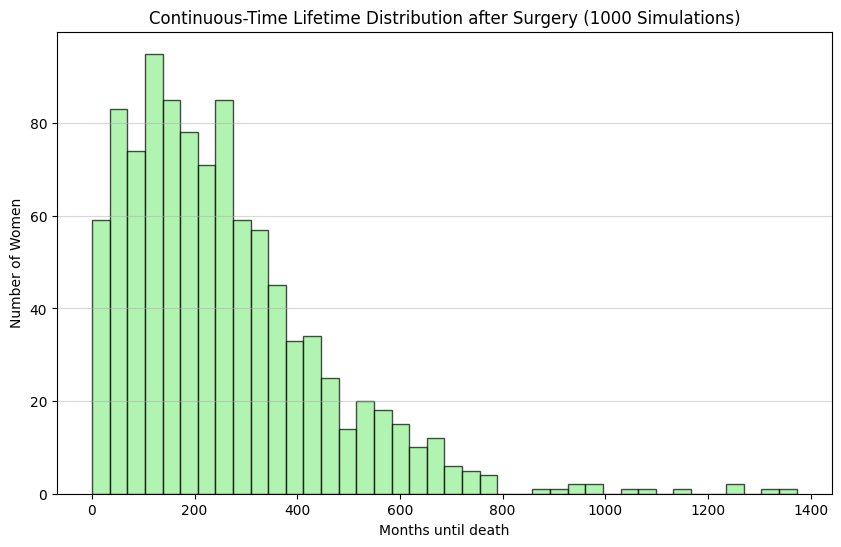

In [52]:
import scipy.stats as stats
np.random.seed(42)  # For reproducibility

Q = np.array([
    [-0.0085, 0.005, 0.0025, 0,     0.001],
    [0,      -0.014, 0.005,  0.004, 0.005],
    [0,      0,     -0.008,  0.003, 0.005],
    [0,      0,     0,      -0.009, 0.009],
    [0,      0,     0,      0,     0]
])


num_women = 1000
lifetimes = []
distant_metastasis_at_305 = 0

for _ in range(num_women):
    current_state = 0  # Start in State 1 (Index 0)
    current_time = 0.0
    had_distant_metastasis_by_305 = False
    
    # Continue simulation until reaching the absorbing state 5 (Index 4)
    while current_state != 4:
        # Rate of leaving the current state is -q_ii
        rate = -Q[current_state, current_state]
        
        # Sample the holding/sojourn time in this state
        sojourn_time = np.random.exponential(1.0 / rate)
        
        # Check if the patient is in a distant metastasis state (State 3 or State 4)
        # during the window up to 30.5 months
        if current_state == 2 or current_state == 3:
            if current_time <= 30.5:
                had_distant_metastasis_by_305 = True
        elif current_time < 30.5 and (current_time + sojourn_time) >= 30.5:
            # If the transition happens across the 30.5-month threshold,
            # we check if their current state during that snapshot was state 3 or 4
            if current_state == 2 or current_state == 3:
                had_distant_metastasis_by_305 = True

        # Advance the clock
        current_time += sojourn_time
        
        # Determine transition probabilities to OTHER states
        row_rates = np.copy(Q[current_state, :])
        row_rates[current_state] = 0  # Cannot jump to itself
        probabilities = row_rates / rate
        
        # Move to the next state
        current_state = np.random.choice(5, p=probabilities)
        
    lifetimes.append(current_time)
    if had_distant_metastasis_by_305:
        distant_metastasis_at_305 += 1

lifetimes = np.array(lifetimes)

# 2. Calculate Metrics and Confidence Intervals
mean_lifetime = np.mean(lifetimes)
std_lifetime = np.std(lifetimes, ddof=1)

# 95% Confidence Interval for the Mean
mean_se = std_lifetime / np.sqrt(num_women)
mean_ci = stats.t.interval(0.95, df=num_women-1, loc=mean_lifetime, scale=mean_se)

# 95% Confidence Interval for the Standard Deviation (using Chi-Square distribution)
chi2_lower = stats.chi2.ppf(0.025, df=num_women-1)
chi2_upper = stats.chi2.ppf(0.975, df=num_women-1)
std_ci_lower = np.sqrt((num_women - 1) * (std_lifetime**2) / chi2_upper)
std_ci_upper = np.sqrt((num_women - 1) * (std_lifetime**2) / chi2_lower)

proportion_distant_305 = distant_metastasis_at_305 / num_women

# 3. Print Summary Reports
print("--- Continuous-Time Simulation Summary ---")
print(f"Mean Lifetime:         {mean_lifetime:.2f} months | 95% CI: ({mean_ci[0]:.2f}, {mean_ci[1]:.2f})")
print(f"Standard Deviation:    {std_lifetime:.2f} months | 95% CI: ({std_ci_lower:.2f}, {std_ci_upper:.2f})")
print(f"Proportion with distant metastasis at 30.5 months: {proportion_distant_305:.4f}")

# 4. Plot the Lifetime Distribution
plt.figure(figsize=(10, 6))
plt.hist(lifetimes, bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('Continuous-Time Lifetime Distribution after Surgery (1000 Simulations)')
plt.xlabel('Months until death')
plt.ylabel('Number of Women')
plt.grid(axis='y', alpha=0.5)
plt.savefig("continuous_time_lifetime_distribution.png")
plt.show()

--- Continuous Validation: K-S Test ---
K-S Statistic: 0.0240
P-value:       0.9358
Conclusion: We fail to reject the null hypothesis.
The empirical lifetime distribution matches the theoretical continuous phase-type distribution.


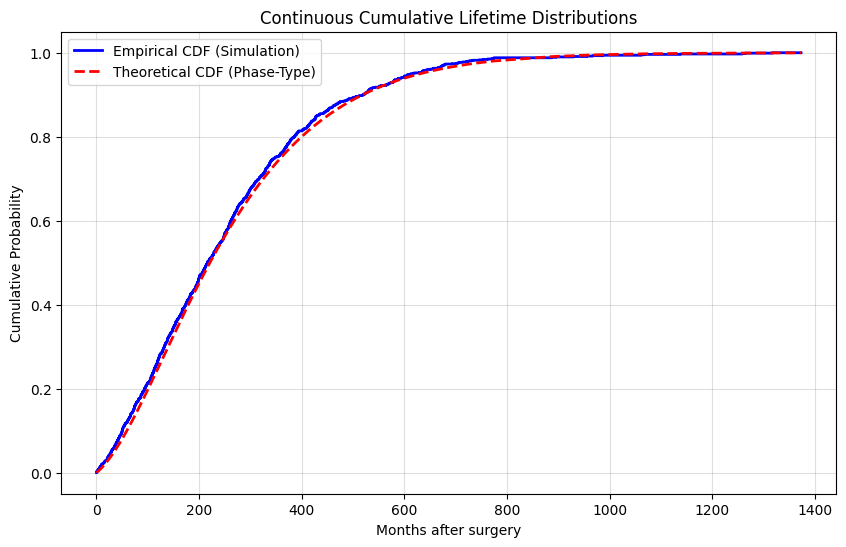

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.stats import ks_2samp
np.random.seed(42)  # For reproducibility
# Extract sub-matrix Q_s (removing the last row and column)
Q_s = Q[0:4, 0:4]
pi_0 = np.array([1, 0, 0, 0])
ones = np.ones(4)

# 2. Re-run Continuous Simulation to get lifetimes (Task 7 setup)
num_women = 1000
simulated_lifetimes = []

for _ in range(num_women):
    current_state = 0
    current_time = 0.0
    while current_state != 4:
        rate = -Q[current_state, current_state]
        sojourn_time = np.random.exponential(1.0 / rate)
        current_time += sojourn_time
        
        row_rates = np.copy(Q[current_state, :])
        row_rates[current_state] = 0
        probabilities = row_rates / rate
        current_state = np.random.choice(5, p=probabilities)
        
    simulated_lifetimes.append(current_time)

simulated_lifetimes = np.sort(simulated_lifetimes)

# 3. Calculate the Exact Theoretical CDF Values
# For each simulated lifetime, we calculate what the theoretical CDF says the probability should be
theoretical_cdf_vals = []
for t in simulated_lifetimes:
    # F(t) = 1 - pi_0 * expm(Q_s * t) * 1
    matrix_exponential = expm(Q_s * t)
    cdf_t = 1.0 - (pi_0 @ matrix_exponential @ ones)
    theoretical_cdf_vals.append(cdf_t)

theoretical_cdf_vals = np.array(theoretical_cdf_vals)

# 4. Perform the Kolmogorov-Smirnov Statistical Test
# We compare our empirical data to a generated sample following the theoretical CDF values
empirical_cdf_vals = np.arange(1, num_women + 1) / num_women
ks_stat, p_value = ks_2samp(empirical_cdf_vals, theoretical_cdf_vals)

print("--- Continuous Validation: K-S Test ---")
print(f"K-S Statistic: {ks_stat:.4f}")
print(f"P-value:       {p_value:.4f}")

if p_value > 0.05:
    print("Conclusion: We fail to reject the null hypothesis.")
    print("The empirical lifetime distribution matches the theoretical continuous phase-type distribution.")
else:
    print("Conclusion: We reject the null hypothesis.")
    print("There is a significant difference between the simulation and theory.")

# 5. Visualizing the Validation Curves
plt.figure(figsize=(10, 6))

# Plot Empirical CDF
plt.step(simulated_lifetimes, empirical_cdf_vals, label='Empirical CDF (Simulation)', color='blue', linewidth=2)

# Plot Theoretical CDF
plt.plot(simulated_lifetimes, theoretical_cdf_vals, label='Theoretical CDF (Phase-Type)', color='red', linestyle='--', linewidth=2)

plt.title('Continuous Cumulative Lifetime Distributions')
plt.xlabel('Months after surgery')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True, alpha=0.4)
plt.savefig("continuous_cdf_comparison.png")
plt.show()

Simulating untreated group...
Simulating treated group...


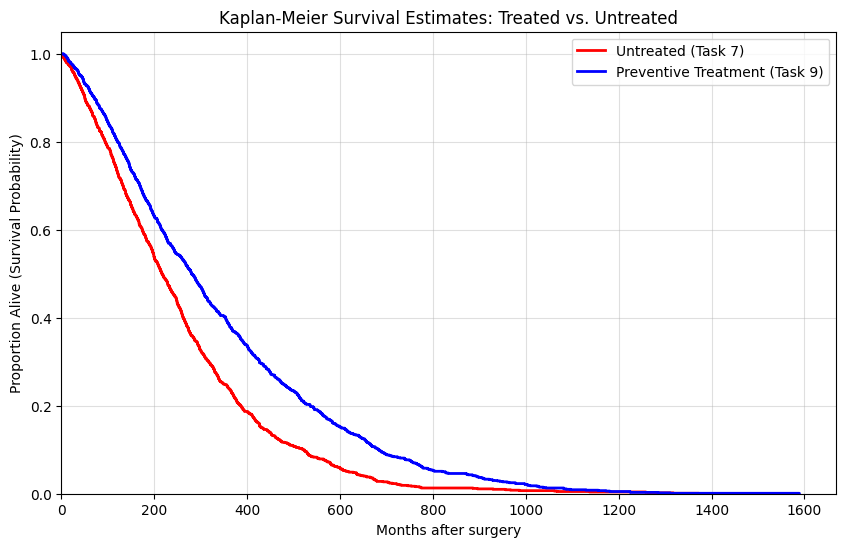


Mean Lifetime (Untreated): 256.37 months
Mean Lifetime (Treated):   338.45 months


In [59]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)  # For reproducibility
# 1. Define both transition-rate matrices
# Untreated matrix (from Task 7)
Q_untreated = np.array([
    [-0.0085,  0.005,   0.0025,  0,       0.001],
    [ 0,      -0.014,   0.005,   0.004,   0.005],
    [ 0,       0,      -0.008,   0.003,   0.005],
    [ 0,       0,       0,      -0.009,   0.009],
    [ 0,       0,       0,       0,       0.0  ]
])

# Treated matrix (with newly calculated diagonal elements)
# Treated matrix (Corrected)
Q_treated = np.array([
    [-0.00475, 0.0025, 0.00125, 0,     0.001],
    [ 0,      -0.007,  0,       0.002, 0.005],
    [ 0,       0,     -0.008,   0.003, 0.005],
    [ 0,       0,      0,      -0.009, 0.009],
    [ 0,       0,      0,       0,     0.0  ]
])

num_women = 1000

# 2. Create a reusable function for the CTMC simulation
def simulate_ctmc(Q, num_patients):
    lifetimes = np.zeros(num_patients)
    
    for i in range(num_patients):
        current_state = 0
        current_time = 0.0
        
        while current_state != 4:
            rate = -Q[current_state, current_state]
            sojourn_time = np.random.exponential(1.0 / rate)
            current_time += sojourn_time
            
            row_rates = np.copy(Q[current_state, :])
            row_rates[current_state] = 0
            probabilities = row_rates / rate
            
            current_state = np.random.choice(5, p=probabilities)
            
        lifetimes[i] = current_time
        
    return np.sort(lifetimes)

# 3. Run simulations for both groups
print("Simulating untreated group...")
lifetimes_untreated = simulate_ctmc(Q_untreated, num_women)

print("Simulating treated group...")
lifetimes_treated = simulate_ctmc(Q_treated, num_women)

# 4. Calculate Kaplan-Meier Survival Estimates
# S(t) starts at 1.0 (100% survival) and drops by 1/N for each death
survival_probs = 1.0 - (np.arange(1, num_women + 1) / num_women)

# Insert starting points (t=0, S(t)=1) to make the plot start correctly at the y-axis
t_untreated = np.insert(lifetimes_untreated, 0, 0)
t_treated = np.insert(lifetimes_treated, 0, 0)
s_probs = np.insert(survival_probs, 0, 1.0)

# 5. Plotting the Kaplan-Meier Curves
plt.figure(figsize=(10, 6))

# Use step plots for Kaplan-Meier
plt.step(t_untreated, s_probs, where='post', label='Untreated (Task 7)', color='red', linewidth=2)
plt.step(t_treated, s_probs, where='post', label='Preventive Treatment (Task 9)', color='blue', linewidth=2)

plt.title('Kaplan-Meier Survival Estimates: Treated vs. Untreated')
plt.xlabel('Months after surgery')
plt.ylabel('Proportion Alive (Survival Probability)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.xlim(left=0)
plt.ylim(0, 1.05)
plt.show()

# Print mean lifetimes for numerical context
print(f"\nMean Lifetime (Untreated): {np.mean(lifetimes_untreated):.2f} months")
print(f"Mean Lifetime (Treated):   {np.mean(lifetimes_treated):.2f} months")

12

In [72]:
import numpy as np

# 1. Define the original transition-rate matrix Q
Q = np.array([
    [-0.0085,  0.005,   0.0025,  0,       0.001],
    [ 0,      -0.014,   0.005,   0.004,   0.005],
    [ 0,       0,      -0.008,   0.003,   0.005],
    [ 0,       0,       0,      -0.009,   0.009],
    [ 0,       0,       0,       0,       0.0  ]
])

Q = Q_treated
np.random.seed(42)
num_women = 1000
observation_interval = 48.0
observed_data = []

# 2. Simulate the observational time series
for _ in range(num_women):
    current_state = 0  # Start in State 1 (Index 0)
    current_time = 0.0
    target_time = 0.0
    time_series = []
    
    while current_state != 4:
        # Determine how long the patient stays in the current state
        rate = -Q[current_state, current_state]
        sojourn_time = np.random.exponential(1.0 / rate)
        next_transition_time = current_time + sojourn_time
        
        # If an observation interval occurs while the patient is in this state, record it
        while target_time < next_transition_time:
            time_series.append(current_state)
            target_time += observation_interval
            
        # Move to the next state and advance the continuous clock
        current_time = next_transition_time
        row_probs = np.copy(Q[current_state, :])
        row_probs[current_state] = 0
        row_probs /= rate
        current_state = np.random.choice(5, p=row_probs)
        
    # The patient has reached the absorbing state (State 5, Index 4)
    # The assignment requires the final recorded observation to be the death state
    time_series.append(4)
    
    observed_data.append(time_series)

# 3. Print a sample of the generated time series to verify
print("--- Sample Observational Time Series (States 1-5) ---")
for i in range(5):
    # Convert Python indices (0-4) back to text State numbers (1-5) for readable output
    display_series = [state + 1 for state in observed_data[i]]
    
    # Calculate the lifetime recorded by the final observation for context
    final_obs_month = (len(display_series) - 1) * int(observation_interval)
    
    print(f"Woman {i+1}: {display_series}")
    print(f"          -> Death observed at month {final_obs_month}\n")

--- Sample Observational Time Series (States 1-5) ---
Woman 1: [1, 1, 1, 5]
          -> Death observed at month 144

Woman 2: [1, 1, 1, 1, 1, 1, 3, 5]
          -> Death observed at month 336

Woman 3: [1, 1, 1, 1, 1, 5]
          -> Death observed at month 240

Woman 4: [1, 1, 1, 1, 1, 1, 1, 1, 2, 4, 5]
          -> Death observed at month 480

Woman 5: [1, 1, 1, 2, 2, 2, 4, 5]
          -> Death observed at month 336



In [75]:
import numpy as np
np.random.seed(42)  # For reproducibility
# --- 1. Initial Setup ---
# We need an initial guess for Q^(0). 
# If we start too far from the truth, rejection sampling will take days to find a valid path.
# For practical purposes, we use a matrix close to the expected structure.
Q_initial = np.array([
    [-0.010,  0.006,  0.003,  0.000,  0.001],
    [ 0.000, -0.015,  0.006,  0.004,  0.005],
    [ 0.000,  0.000, -0.010,  0.004,  0.006],
    [ 0.000,  0.000,  0.000, -0.010,  0.010],
    [ 0.000,  0.000,  0.000,  0.000,  0.000]
])

def simulate_bridge(y_start, y_end, Q_current, interval=48.0):
    """
    Simulates a continuous path between two observations using rejection sampling.
    Returns the sojourn times (S) and jump counts (N) for the accepted path.
    """
    # If starting in the absorbing state, no simulation needed
    if y_start == 4:
        path_S = np.zeros(5)
        path_N = np.zeros((5, 5))
        path_S[4] = interval
        return path_S, path_N

    while True:
        path_S = np.zeros(5)
        path_N = np.zeros((5, 5))
        current_state = y_start
        current_time = 0.0

        while current_time < interval:
            rate = -Q_current[current_state, current_state]
            
            # If we hit the absorbing state early, stay there for the rest of the interval
            if rate == 0:
                path_S[current_state] += (interval - current_time)
                current_time = interval
                break

            sojourn_time = np.random.exponential(1.0 / rate)

            # Check if the transition happens after the observation interval ends
            if current_time + sojourn_time >= interval:
                path_S[current_state] += (interval - current_time)
                current_time = interval
                break
            else:
                path_S[current_state] += sojourn_time
                current_time += sojourn_time

                # Transition to next state
                row_probs = np.copy(Q_current[current_state, :])
                row_probs[current_state] = 0
                row_probs /= rate
                next_state = np.random.choice(5, p=row_probs)

                path_N[current_state, next_state] += 1
                current_state = next_state

        # Rejection Condition: Only return if the final simulated state matches the observation
        if current_state == y_end:
            return path_S, path_N

def mcem_algorithm(observed_data, Q_start, max_iter=15, tolerance=1e-3):
    Q_k = np.copy(Q_start)
    
    for iteration in range(max_iter):
        print(f"\n--- Starting EM Iteration {iteration + 1} ---")
        
        N_ij_total = np.zeros((5, 5))
        S_i_total = np.zeros(5)
        
        # E-STEP: Reconstruct trajectories for all patients
        for patient_idx, time_series in enumerate(observed_data):
            if (patient_idx + 1) % 200 == 0:
                print(f"  Simulating trajectories for patient {patient_idx + 1}/{len(observed_data)}...")
                
            for obs_idx in range(len(time_series) - 1):
                y_start = time_series[obs_idx]
                y_end = time_series[obs_idx + 1]
                
                # Simulate the bridge between the two 48-month observations
                path_S, path_N = simulate_bridge(y_start, y_end, Q_k, interval=48.0)
                
                # Accumulate the accepted path data
                S_i_total += path_S
                N_ij_total += path_N
                
        # M-STEP: Update the transition rates
        Q_next = np.zeros((5, 5))
        
        for i in range(4): # State 5 is absorbing, so rates are 0
            for j in range(5):
                if i != j and S_i_total[i] > 0:
                    Q_next[i, j] = N_ij_total[i, j] / S_i_total[i]
                    
        # Update diagonal elements to ensure row sums equal 0
        for i in range(4):
            Q_next[i, i] = -np.sum(Q_next[i, :])
            
        # Check for convergence using the infinity norm
        max_difference = np.max(np.abs(Q_k - Q_next))
        print(f"  Maximum matrix difference: {max_difference:.6f}")
        
        Q_k = np.copy(Q_next)
        
        if max_difference < tolerance:
            print(f"\nConvergence reached after {iteration + 1} iterations!")
            break
            
    return Q_k

# --- 3. Execute the Algorithm ---
# Assuming 'observed_data' exists in your workspace from Task 12
print("Initializing MCEM Algorithm. This will take some time due to rejection sampling...")
estimated_Q = mcem_algorithm(observed_data, Q_initial)

print("\n--- Final Estimated Transition-Rate Matrix Q ---")
np.set_printoptions(precision=5, suppress=True)
print(estimated_Q, Q_treated)

difference_matrix = estimated_Q - Q
print("\n--- Are the estimated rates close to the original Q? ---")
print(np.allclose(estimated_Q, Q, atol=0.01))  # Check if they are close within a reasonable tolerance

Initializing MCEM Algorithm. This will take some time due to rejection sampling...

--- Starting EM Iteration 1 ---
  Simulating trajectories for patient 200/1000...
  Simulating trajectories for patient 400/1000...
  Simulating trajectories for patient 600/1000...
  Simulating trajectories for patient 800/1000...
  Simulating trajectories for patient 1000/1000...
  Maximum matrix difference: 0.006257

--- Starting EM Iteration 2 ---
  Simulating trajectories for patient 200/1000...
  Simulating trajectories for patient 400/1000...
  Simulating trajectories for patient 600/1000...
  Simulating trajectories for patient 800/1000...
  Simulating trajectories for patient 1000/1000...
  Maximum matrix difference: 0.001072

--- Starting EM Iteration 3 ---
  Simulating trajectories for patient 200/1000...
  Simulating trajectories for patient 400/1000...
  Simulating trajectories for patient 600/1000...
  Simulating trajectories for patient 800/1000...
  Simulating trajectories for patient 10